# Gwas

In [74]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats

In [75]:
phenotypes = pd.read_csv("/home/user/papkamusik/action_folder/GWAS/filtered_gwas_pheno.csv")
genotypes = pd.read_csv("/home/user/papkamusik/action_folder/GWAS/voice_genotypes.csv")
# covariates = pd.read_csv("covariates.csv")

In [76]:
df_clean = phenotypes[["call_id", "f0_median", "f0_variance"]]
covariates = phenotypes[["call_id", "age"]]
genotypes

,call_id,rs4655723,rs1514177,rs12759783,rs72901035,rs1345417,rs13179411,rs55972276,rs2964296,rs60875622,...,rs704191,rs10859172,rs9568476,rs8005994,rs12913832,rs3743266,rs246185,rs11079719,rs8081915,rs913001
0,000eeafa47c9420d3504c9206f815440,0/1,0/0,0/0,0/0,1/1,0/1,0/0,./.,0/0,...,0/1,0/1,0/1,0/1,1/1,0/1,0/0,0/0,1/1,./.
1,000f04e6cdd2bcb7bfce7c61fc02d7e3,0/0,0/0,1/1,0/0,0/1,0/1,0/0,./.,0/0,...,0/1,0/1,0/1,0/0,0/0,0/0,0/0,0/1,0/1,1/1
2,001a5f1e38b54988a8dcab0df917988f,0/0,0/1,0/0,0/0,1/1,0/0,0/0,./.,0/1,...,0/0,./.,0/0,0/0,1/1,0/0,0/0,0/1,1/1,1/1
3,001eaba8ad84cbf2dde984be9b751296,0/1,0/1,1/1,0/0,0/1,0/0,0/0,./.,0/1,...,./.,0/1,1/1,0/0,1/1,0/0,0/0,0/0,1/1,1/1
4,00210ced68028f7ec167b3f8ace1aee4,0/0,1/1,0/1,0/0,./.,0/0,0/0,./.,0/1,...,0/0,0/1,0/1,0/0,./.,0/0,./.,0/0,0/1,0/0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9739,fff3050a4b9a261afb04a9ff39724b48,0/1,1/1,1/1,0/0,./.,0/0,0/0,./.,0/1,...,0/1,0/1,0/1,0/1,0/1,0/0,./.,0/0,./.,1/1
9740,fffad12ba6a1d5608bad4be0ccb83330,0/0,0/1,0/1,0/0,./.,0/0,0/0,./.,./.,...,1/1,./.,0/1,0/1,./.,0/1,1/1,0/0,./.,1/1
9741,fffb71c77a7f89e9b0519227ac6b1d7e,0/1,0/1,0/1,0/0,./.,0/0,0/0,./.,0/0,...,0/1,0/0,1/1,0/0,0/1,0/0,0/1,0/0,0/1,0/1
9742,fffdbca2bb6c0c2665296f6a0c0fac4d,0/1,0/1,0/1,0/0,1/1,0/0,0/1,./.,0/0,...,1/1,1/1,0/1,0/0,1/1,0/1,0/0,1/1,0/0,1/1


In [77]:
df = df_clean.merge(genotypes, on="call_id")
df = df.merge(covariates, on="call_id")
df

,call_id,f0_median,f0_variance,rs4655723,rs1514177,rs12759783,rs72901035,rs1345417,rs13179411,rs55972276,...,rs10859172,rs9568476,rs8005994,rs12913832,rs3743266,rs246185,rs11079719,rs8081915,rs913001,age
0,7c749f781537e584be74e1c6231bc0d7,200.632542,1470.666892,0/1,0/0,1/1,0/0,1/1,0/1,0/0,...,0/1,1/1,1/1,1/1,0/1,0/0,0/0,1/1,1/1,40.0
1,4f331c8df6c7daf200725fee910669c7,199.463008,1525.067940,0/0,0/1,0/0,0/1,0/1,0/1,0/0,...,1/1,0/0,0/1,1/1,0/1,0/0,0/1,0/0,1/1,50.0
2,b2934e30184a1f8ab4ef3c336730feef,223.626064,1293.551901,0/1,0/0,1/1,0/0,0/1,0/0,0/0,...,0/1,1/1,0/0,1/1,0/0,0/0,0/1,0/1,1/1,30.0
3,d01d1de7df95e13d551377514332dd90,197.573465,1469.339081,0/0,1/1,0/1,0/0,1/1,0/1,0/1,...,1/1,0/1,0/1,1/1,0/0,./.,0/0,./.,0/1,27.0
4,604c5bafc2ea3b3652ea5c1a635e8e82,202.489490,1235.976861,0/0,0/1,0/1,0/0,1/1,0/1,0/0,...,0/0,1/1,0/0,0/1,0/1,0/0,0/0,0/0,1/1,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,73eb92f89829a8dc903fdd8aa2407a74,111.541789,848.101864,0/1,0/1,0/1,0/0,./.,0/0,0/0,...,1/1,1/1,0/0,1/1,0/0,0/0,0/0,1/1,0/1,67.0
288,e20462103a0d2a59843a0162d08b0a3f,117.158833,661.935339,0/0,1/1,1/1,0/0,1/1,0/0,0/0,...,0/1,0/0,1/1,1/1,0/1,0/0,0/0,0/1,1/1,27.0
289,dda83088c7a3e9e0ff6750ee0048b8e2,112.308462,982.207587,1/1,0/1,1/1,0/0,./.,0/0,0/0,...,0/0,1/1,0/1,./.,0/0,0/0,0/0,0/0,./.,31.0
290,c0f45db39d7c607598b57fbae8c8d0c6,136.774154,837.387153,0/0,1/1,0/1,0/0,./.,1/1,0/0,...,0/1,1/1,0/0,./.,0/1,1/1,0/1,0/1,1/1,61.0


# Этап 4. Определяем переменные

In [78]:
# =========================
# ЭТАП 1. DATA PREPARATION
# =========================

# phenotype (зависимая переменная)
y = df["f0_median"]

# covariates (например возраст и другие факторы)
covars = ["age"]
covariates = df[covars]

# SNP columns (все SNP: колонки 3:33)
snp_cols = df.columns[3:34]

def encode_snp(x):
    if pd.isna(x):
        return np.nan
    if x == "0/0":
        return 0
    if x == "0/1":
        return 1
    if x == "1/1":
        return 2
    return np.nan

df[snp_cols] = df[snp_cols].applymap(encode_snp)

/tmp/ipykernel_79983/1433850268.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[snp_cols] = df[snp_cols].applymap(encode_snp)


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   call_id      292 non-null    object 
 1   f0_median    292 non-null    float64
 2   f0_variance  292 non-null    float64
 3   rs4655723    287 non-null    float64
 4   rs1514177    282 non-null    float64
 5   rs12759783   286 non-null    float64
 6   rs72901035   292 non-null    int64  
 7   rs1345417    179 non-null    float64
 8   rs13179411   287 non-null    float64
 9   rs55972276   292 non-null    int64  
 10  rs2964296    31 non-null     float64
 11  rs60875622   283 non-null    float64
 12  rs314268     285 non-null    float64
 13  rs4728218    288 non-null    float64
 14  rs7032296    239 non-null    float64
 15  rs1516882    287 non-null    float64
 16  rs12003641   291 non-null    float64
 17  rs1597449    282 non-null    float64
 18  rs6265       291 non-null    float64
 19  rs110376

In [80]:
threshold = 0.95

snp_cols = [c for c in df.columns if c.startswith("rs")]

# ========================
# STEP 1: FILTER SNPs
# ========================

valid_snps = [
    col for col in snp_cols
    if df[col].notna().mean() >= threshold
]

invalid_snps = [
    col for col in snp_cols
    if df[col].notna().mean() < threshold
]

print("Dropped SNPs:", invalid_snps)

# ========================
# STEP 2: COPY DATA
# ========================

new_df = df[valid_snps + ["call_id", "f0_median", "age"]].copy()

# ========================
# STEP 3: IMPUTATION (CORRECT)
# ========================

for col in valid_snps:

    # allele frequency считается ДО изменений
    p = new_df[col].mean(skipna=True) / 2

    # imputation
    new_df.loc[:, col] = new_df[col].fillna(2 * p)

Dropped SNPs: ['rs1345417', 'rs2964296', 'rs7032296', 'rs3824915', 'rs704191', 'rs12913832', 'rs246185', 'rs8081915']


In [81]:
print(len(new_df))
new_df.info()

292
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rs4655723   292 non-null    float64
 1   rs1514177   292 non-null    float64
 2   rs12759783  292 non-null    float64
 3   rs72901035  292 non-null    int64  
 4   rs13179411  292 non-null    float64
 5   rs55972276  292 non-null    int64  
 6   rs60875622  292 non-null    float64
 7   rs314268    292 non-null    float64
 8   rs4728218   292 non-null    float64
 9   rs1516882   292 non-null    float64
 10  rs12003641  292 non-null    float64
 11  rs1597449   292 non-null    float64
 12  rs6265      292 non-null    float64
 13  rs11037611  292 non-null    float64
 14  rs7107502   292 non-null    float64
 15  rs2307024   292 non-null    float64
 16  rs11046212  292 non-null    float64
 17  rs10859172  292 non-null    float64
 18  rs9568476   292 non-null    float64
 19  rs8005994   292 non-null 

# Этап 5. Основной GWAS цикл

In [ ]:
# =========================
# ЭТАП 2. GWAS LOOP
# =========================
# phenotype (зависимая переменная)
y = df["f0_median"]

results = []

for snp in tqdm(valid_snps):

    # X = SNP + covariates
    X = new_df[[snp] + covars]
    X = sm.add_constant(X)

    # OLS regression
    model = sm.OLS(y, X).fit()

    beta = model.params[snp]
    p_value = model.pvalues[snp]

    results.append([snp, beta, p_value])

100%|██████████| 23/23 [00:00<00:00, 739.33it/s]


# ЭТАП 3. RESULTS TABLE

In [90]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

# =========================
# GWAS TABLE
# =========================

gwas = pd.DataFrame(results, columns=["SNP", "beta", "p"])

# =========================
# BONFERRONI CORRECTION
# =========================

alpha = 0.05
n_tests = len(gwas)

gwas["bonferroni_threshold"] = alpha / n_tests
gwas["bonferroni_significant"] = gwas["p"] < gwas["bonferroni_threshold"]

# =========================
# FDR (Benjamini-Hochberg)
# =========================

reject, pvals_fdr, _, _ = multipletests(
    gwas["p"].values,
    alpha=0.05,
    method="fdr_bh"
)

gwas["fdr_p"] = pvals_fdr
gwas["fdr_significant"] = reject

gwas

,SNP,beta,p,bonferroni_threshold,bonferroni_significant,fdr_p,fdr_significant
0,rs4655723,1.413517,0.758105,0.002174,False,0.878129,False
1,rs1514177,-1.393643,0.735768,0.002174,False,0.878129,False
2,rs12759783,0.382276,0.925252,0.002174,False,0.925252,False
3,rs72901035,3.007405,0.625166,0.002174,False,0.878129,False
4,rs13179411,-5.189128,0.348767,0.002174,False,0.848212,False
5,rs55972276,-5.884343,0.370310,0.002174,False,0.848212,False
6,rs60875622,-1.109834,0.798377,0.002174,False,0.878129,False
7,rs314268,-1.314412,0.763691,0.002174,False,0.878129,False
8,rs4728218,-1.261340,0.750072,0.002174,False,0.878129,False
9,rs1516882,3.583664,0.405667,0.002174,False,0.848212,False


# ЭТАП 4. MANHATTAN PLOT

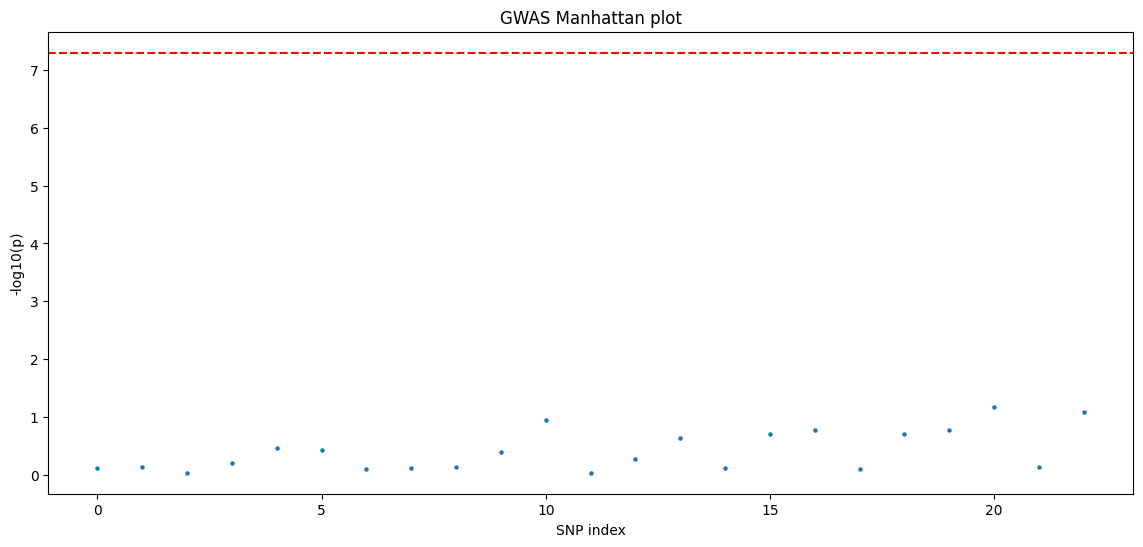

In [86]:
gwas["-log10(p)"] = -np.log10(gwas["p"])

plt.figure(figsize=(14, 6))

plt.scatter(
    range(len(gwas)),
    gwas["-log10(p)"],
    s=5
)

# genome-wide significance threshold
plt.axhline(-np.log10(5e-8), color="red", linestyle="--")

plt.xlabel("SNP index")
plt.ylabel("-log10(p)")
plt.title("GWAS Manhattan plot")

plt.show()

# QQ PLOT

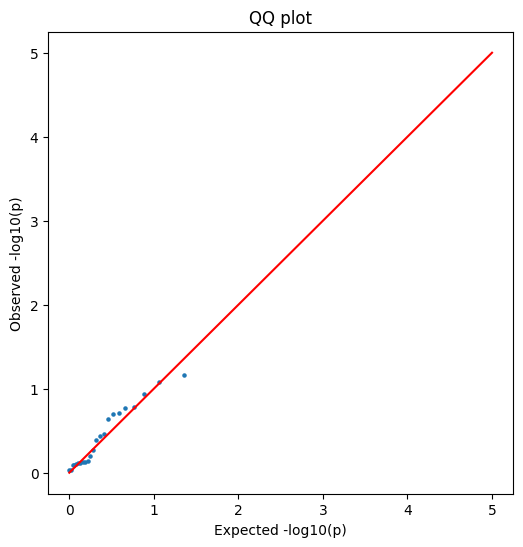

In [87]:
pvals = np.sort(gwas["p"].values)

expected = np.arange(1, len(pvals) + 1) / len(pvals)

plt.figure(figsize=(6, 6))

plt.scatter(
    -np.log10(expected),
    -np.log10(pvals),
    s=5
)

plt.plot([0, 5], [0, 5], color="red")

plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("QQ plot")

plt.show()